---
title: "Homework 4: Classification Inference, Trees, and Unsupervised Learning"
subtitle: "MSE 125 — Spring 2026"
date: "Due: Monday, May 25, 2026 at 11:59 PM"
execute:
  enabled: true
jupyter: python3
---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             silhouette_score)
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

DATA_DIR = 'data'

### Load the bankruptcy data

Problems 1–3 use the Taiwanese Bankruptcy Prediction dataset: 6,819 companies listed on the Taiwan Stock Exchange between 1999 and 2009, each described by 95 financial ratios computed from its statements — profitability, leverage, liquidity, efficiency — and a label, `Bankrupt?`, marking whether the company went bankrupt. The cell below loads it; if you don't already have the CSV, it downloads and unzips the dataset from the UCI Machine Learning Repository (~5 MB).

In [2]:
import os, urllib.request, zipfile

BANK_DIR = f"{DATA_DIR}/bankruptcy"
CSV = f"{BANK_DIR}/bankruptcy.csv"
URL = ("https://archive.ics.uci.edu/static/public/572/"
       "taiwanese+bankruptcy+prediction.zip")

if not os.path.exists(CSV):
    os.makedirs(BANK_DIR, exist_ok=True)
    zip_path = f"{BANK_DIR}/tw.zip"
    print("Downloading Taiwanese bankruptcy data from UCI...")
    urllib.request.urlretrieve(URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(BANK_DIR)
    os.rename(f"{BANK_DIR}/data.csv", CSV)
    os.remove(zip_path)

bankruptcy = pd.read_csv(CSV)
bankruptcy.columns = [c.strip() for c in bankruptcy.columns]
# one column ('Net Income Flag') is constant — drop it
bankruptcy = bankruptcy.drop(columns=['Net Income Flag'])
FEATURES = [c for c in bankruptcy.columns if c != 'Bankrupt?']
print(f"Loaded {len(bankruptcy):,} companies x {len(FEATURES)} financial ratios")
print(f"Bankruptcy rate: {bankruptcy['Bankrupt?'].mean():.1%}")

Loaded 6,819 companies x 94 financial ratios
Bankruptcy rate: 3.2%


## How to use this notebook

Write your answers in the cells marked `# Your code here` or *Your answer here* below each question. Add more cells if you need them (Insert > Code cell or Text cell). Run each code cell with Shift+Enter.

## Submission

Submit your completed notebook (.ipynb) to Gradescope by the due date. Run all cells top-to-bottom before saving so your outputs are included. Problem 4 has a separate submission step described in that problem.

## Problem 1: Which financial ratios actually flag bankruptcy risk?

You work on the commercial lending desk of a bank. Before the desk extends a loan to a company, an analyst hands the credit committee a sheet of 95 financial ratios — and the committee's eyes glaze over. They want a short underwriting rule: *which* ratios genuinely move the odds that a borrower goes bankrupt, by *how much*, and in *which direction*. You'll fit a logistic regression, read its coefficients as odds ratios, and tell the committee which ratios belong on the rule and which don't.

Work with this set of ten interpretable, well-scaled ratios:

In [3]:
RATIOS = [
    'ROA(C) before interest and depreciation before interest',
    'Operating Gross Margin',
    'Debt ratio %',
    'Total Asset Turnover',
    'Cash/Total Assets',
    'Retained Earnings to Total Assets',
    'Net Income to Total Assets',
    'Working Capital to Total Assets',
    'Equity to Liability',
    'Borrowing dependency',
]
y = bankruptcy['Bankrupt?'].values

**(a)** Standardize the ten ratios (so each is on a common scale) and fit a logistic regression of `Bankrupt?` on them using `statsmodels` — `sm.Logit(y, sm.add_constant(X_std)).fit()`, then `.summary()`. Report the coefficient table. Which ratios are statistically significant at the 0.05 level, and which are not?

In [4]:
X = bankruptcy[RATIOS].values
X_std = StandardScaler().fit_transform(X)

model = sm.Logit(y, sm.add_constant(X_std)).fit()
print(model.summary(xname=['const'] + RATIOS))

Optimization terminated successfully.
         Current function value: 0.091947
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 6819
Model:                          Logit   Df Residuals:                     6808
Method:                           MLE   Df Model:                           10
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.3549
Time:                        11:49:52   Log-Likelihood:                -626.99
converged:                       True   LL-Null:                       -971.86
Covariance Type:            nonrobust   LLR p-value:                9.993e-142
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
const            

Significant: ROA(C) before interest and depreciation, Debt ratio %, Total Asset Turnover, Cash/Total Assets, Retained Earnings to Total Assets, Net Income to Total Assets, Equity to Liability.
Not significant: Operating Gross Margin, Working Capital to Total Assets, Borrowing dependency.

**(b)** A coefficient in a logistic regression becomes an **odds ratio** when you exponentiate it: `np.exp(coef)`. Because you standardized the ratios, each odds ratio describes the effect of a *one-standard-deviation* increase in that ratio. Pick the two ratios with the largest effects (one that raises bankruptcy odds, one that lowers them) and write one sentence each, in plain language the credit committee would understand — no jargon, no equations.

In [6]:
odds_ratios = pd.DataFrame({
    'coef': model.params[1:],
    'odds_ratio': np.exp(model.params[1:]),
    'p_value': model.pvalues[1:],
}, index=RATIOS).sort_values('odds_ratio')
print(odds_ratios)

                                                        coef  odds_ratio  \
Cash/Total Assets                                  -0.930412    0.394391   
Net Income to Total Assets                         -0.692903    0.500122   
ROA(C) before interest and depreciation before ... -0.560681    0.570820   
Total Asset Turnover                               -0.537690    0.584096   
Working Capital to Total Assets                    -0.159777    0.852334   
Borrowing dependency                                0.010119    1.010171   
Operating Gross Margin                              0.029939    1.030392   
Equity to Liability                                 0.239352    1.270426   
Retained Earnings to Total Assets                   0.434816    1.544679   
Debt ratio %                                        1.099283    3.002011   

                                                         p_value  
Cash/Total Assets                                   2.222116e-05  
Net Income to Total Assets   

Debt ratio where a company with unusually high debt is about three times as likely to go bankrupt as a typical company. Cash/total assets where holding more cash relative to its size is about 60 percent less likely to go bankrupt

**(c)** Several of these ratios measure overlapping aspects of a company's finances. Compute the correlation matrix of the ten standardized ratios and identify the most strongly correlated pairs. In 2–3 sentences, explain what heavy correlation among predictors does to a logistic regression's coefficients and standard errors — and why it makes the individual coefficients harder to interpret. (You will return to this problem in Problem 3.)

In [7]:
corr = pd.DataFrame(X_std, columns=RATIOS).corr()

pairs = (corr.where(~np.eye(len(corr), dtype=bool))
             .stack()
             .sort_values(key=abs, ascending=False))
print(pairs.head(6))

ROA(C) before interest and depreciation before interest  Net Income to Total Assets                                 0.887670
Net Income to Total Assets                               ROA(C) before interest and depreciation before interest    0.887670
Retained Earnings to Total Assets                        Net Income to Total Assets                                 0.794189
Net Income to Total Assets                               Retained Earnings to Total Assets                          0.794189
Retained Earnings to Total Assets                        ROA(C) before interest and depreciation before interest    0.650217
ROA(C) before interest and depreciation before interest  Retained Earnings to Total Assets                          0.650217
dtype: float64


ROA(C) and Net Income to Total Assets have high correlations. Both with Retained Earnings to Total Assets. There are a lot of overlaps which means the model can't tell which one is doing the work. Ratio can look small here even when it matters on its won.

**(d)** With 6,819 companies, statistical significance is cheap — many coefficients clear the 0.05 bar. The credit committee cannot act on a p-value; they need to know which ratios move the odds by a large enough amount to act on. Using the standardized odds ratios from (b), identify the one or two ratios with a large enough effect to belong on the underwriting rule, and name one ratio that is statistically significant but whose effect is too small to be worth flagging. Then write the one-sentence underwriting rule the committee asked for.

The two ratios big enough to act on are Debt ratio and Cash/Total Assets. Equity to Liability is significant but too small to flag since it moves the odds only about 27%. The rule would be flag a borrower when it owes a lot or holds little cash

## Problem 2: Trees and forests — a better bankruptcy screen?

The lending desk's current screen is a logistic regression like the one in Problem 1. Your job is to find out whether a tree-based model predicts bankruptcy better, and what the desk would give up by switching.

In [9]:
X = bankruptcy[FEATURES].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

**(a)** Fit the desk's current screen — a logistic regression on all 94 standardized financial ratios — and report its test AUC. (Standardize using statistics from the training set only.)

In [10]:
scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

logit = LogisticRegression(max_iter=1000).fit(X_train_std, y_train)
logit_auc = roc_auc_score(y_test, logit.predict_proba(X_test_std)[:, 1])
print(f"Logistic regression test AUC = {logit_auc:.3f}")

Logistic regression test AUC = 0.866


*Your answer here.*

**(b)** Fit a single decision tree. Use cross-validation on the training set to choose `max_depth`, trying a range from very shallow to unrestricted. Report the depth you chose and how you chose it, then report that tree's training AUC and test AUC. What happens to the gap between training and test AUC as the tree gets deeper, and what is that gap called?

In [11]:
depths = [1, 2, 3, 4, 5, 7, 10, 15, 20, None]
cv_means = []
for d in depths:
    scores = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42),
                             X_train, y_train, cv=5, scoring='roc_auc')
    cv_means.append(scores.mean())
    print(f"depth={str(d):>4s}: CV AUC = {scores.mean():.3f}")

best_depth = depths[np.argmax(cv_means)]
print(f"\nBest depth by CV: {best_depth}")

tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42).fit(X_train, y_train)
tree_train_auc = roc_auc_score(y_train, tree.predict_proba(X_train)[:, 1])
tree_test_auc = roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1])
print(f"Tree (depth={best_depth}): train AUC = {tree_train_auc:.3f} | test AUC = {tree_test_auc:.3f}")

depth=   1: CV AUC = 0.662
depth=   2: CV AUC = 0.850
depth=   3: CV AUC = 0.855
depth=   4: CV AUC = 0.838
depth=   5: CV AUC = 0.797
depth=   7: CV AUC = 0.708
depth=  10: CV AUC = 0.593
depth=  15: CV AUC = 0.626
depth=  20: CV AUC = 0.625
depth=None: CV AUC = 0.625

Best depth by CV: 3
Tree (depth=3): train AUC = 0.888 | test AUC = 0.844


CV picked depth 3 as the highest CV AUC. The tree gets train 0.888 and test 0.844. As the tree gets deeper, training AUC keep rising toward 1 while test fails. That gap means it is overfitting.

**(c)** Fit a random forest (at least 200 trees). Report its test AUC and compare it to the logistic regression from (a) and the single tree from (b). The forest's AUC is higher than the logistic regression's — but is the edge real or noise? Bootstrap a 95% confidence interval for the *difference* in test AUC (forest minus logistic): resample the test-set rows with replacement (1,000 times), recompute *both* models' AUC on each resample, and take the 2.5th and 97.5th percentiles of the difference. Does the interval exclude 0? Finally, in 1–2 sentences: a single deep tree overfits badly, yet a forest of such trees does not — explain why averaging many overfit trees produces a model that generalizes.

In [13]:
forest = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
forest_auc = roc_auc_score(y_test, forest.predict_proba(X_test)[:, 1])
print(f"Logistic = {logit_auc:.3f} | Tree = {tree_test_auc:.3f} | Forest = {forest_auc:.3f}")

Logistic = 0.866 | Tree = 0.844 | Forest = 0.947


In [14]:
p_forest = forest.predict_proba(X_test)[:, 1]
p_logit = logit.predict_proba(X_test_std)[:, 1]

rng = np.random.default_rng(42)
n = len(y_test)
diffs = []

for i in range(1000):
    rows = rng.integers(0, n, n)
    auc_f = roc_auc_score(y_test[rows], p_forest[rows])
    auc_l = roc_auc_score(y_test[rows], p_logit[rows])
    diffs.append(auc_f - auc_l)

lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"95% CI for forest - logistic AUC = [{lo:.3f}, {hi:.3f}]")

95% CI for forest - logistic AUC = [0.028, 0.147]


The interval excludes 0. Each tree overfits different random noise, so averaging them cancels the noise while keeping the signal they agree on

**(d)** Only 3.2% of these companies went bankrupt, so a model that flags *no one* is 96.8% "accurate" — accuracy is the wrong metric here. The desk will flag the riskiest **10%** of loan applicants for senior review. For both the logistic regression and the random forest, compute the precision and recall among each model's top-10% riskiest picks. (To pick out the top 10%, threshold each model's predicted probabilities at their 90th percentile, then compare those flagged rows to the true labels with `precision_score` and `recall_score`.) Write a short paragraph (4–6 sentences) to the desk's credit committee recommending one model. Your recommendation must cite the precision and recall numbers, explain why accuracy would have been misleading, and note one concrete thing the committee gives up if you recommend the forest over the logistic regression.

In [15]:
logit_flag = p_logit >= np.percentile(p_logit, 90)
print("Logistic:", precision_score(y_test, logit_flag), recall_score(y_test, logit_flag))

forest_flag = p_forest >= np.percentile(p_forest, 90)
print("Forest:", precision_score(y_test, forest_flag), recall_score(y_test, forest_flag))

Logistic: 0.19883040935672514 0.6181818181818182
Forest: 0.24561403508771928 0.7636363636363637


We recommend the random forest. In each model's riskiest 10%, the forest catches 76% of real bankruptcies at 25% precision, versus the logistic's 62% recall and 20% precision, so it catches more. Accuracy is misleading here: only 3.2% go bankrupt, so flagging no one scores 96.8% while catching nothing. The logistic tells you which ratios drive the score, the forest can't.

## Problem 3: Does PCA fix the collinear-ratio problem?

> **A note on this problem.** This problem is intentionally less prescriptive than the earlier ones. We do not tell you how many principal components to keep, how many clusters to form, or how to fold either one into a classifier — your future collaborators won't either. They will pitch you an idea and a goal, and expect *you* to design the test. The sub-parts below give you the situational context: the baselines you are trying to beat (your Problem 2 models), the two proposals on the table, and the deliverable. Your job is to turn that into an analysis.
>
> To keep grading tractable, the problem requires specific artifacts and a short decision log. The rubric evaluates the *quality of your choices and reasoning*, not whether they match a hidden answer key — multiple paths earn full credit if defended well.
>
> **Required deliverables.**
>
> 1. **(a)** A scree plot and a logistic classifier trained on principal components alone, compared to the Problem 2 logistic baseline.
> 2. **(b)** A short analysis of what structure PCA found in the ratios and why it relates to bankruptcy.
> 3. **(c)** Tests of the limits — PCA with the forest, PCA as an add-on, and k-means clusters — plus a 4-row decision log.
> 4. **(d)** A memo delivering the verdict.
>
> **Grading rubric (50 pts).** PCA pipeline is correct and the comparison to baseline is fair (10) · the analysis in (b) correctly identifies what the top component captures and why it predicts bankruptcy (15) · the limit tests in (c) are fair and the decision log states *why*, not just *what* (10) · the memo gives one clear verdict grounded in the numbers and states the general principle (15).

In Problem 1(c) you saw the catch with the financial ratios: many of them measure overlapping things, and that collinearity makes a logistic regression's coefficients unstable and hard to read. The lending desk's data science team has two proposals for getting around it:

1. **"Compress the ratios."** Use PCA to turn the 94 collinear ratios into a handful of uncorrelated principal components, and fit the logistic screen on those instead.
2. **"Bucket the companies."** Use k-means to group companies into a few financial "profiles," and feed each company's profile to the classifier as a feature.

They want to know whether either idea actually improves the bankruptcy screen — or whether they are sophisticated-sounding detours. You will test both against your Problem 2 models and give them a verdict.

**(a)** Run PCA on the standardized financial ratios (fit on the training set only). Show a scree plot. Decide how many components to keep and justify the choice. Then train a logistic regression using *only* the principal components as features, and compare its test AUC to your Problem 2 logistic baseline (the one on all 94 raw ratios). Does compressing the ratios help, hurt, or neither?

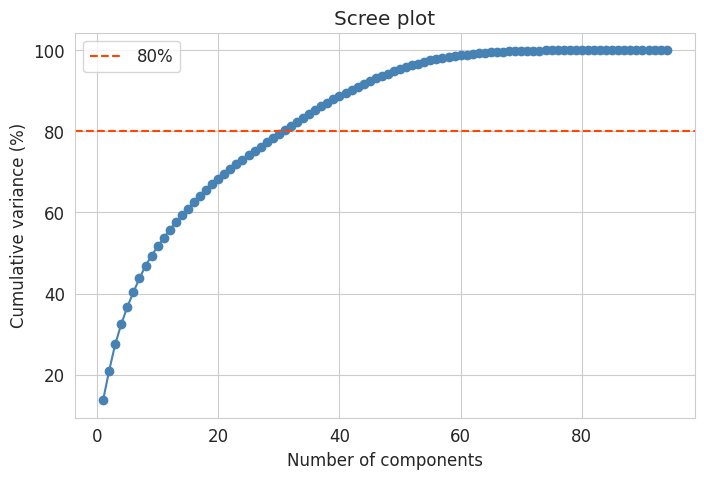

31 components reach 80% variance


In [16]:
pca_scaler = StandardScaler().fit(X_train)
X_train_sc = pca_scaler.transform(X_train)
X_test_sc = pca_scaler.transform(X_test)

pca = PCA().fit(X_train_sc)
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

plt.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='steelblue')
plt.axhline(80, color='orangered', linestyle='--', label='80%')
plt.xlabel('Number of components'); plt.ylabel('Cumulative variance (%)')
plt.title('Scree plot'); plt.legend(); plt.show()

n_pcs = np.argmax(cumvar >= 80) + 1
print(f"{n_pcs} components reach 80% variance")

In [17]:
pca_k = PCA(n_components=n_pcs).fit(X_train_sc)
Z_train = pca_k.transform(X_train_sc)
Z_test = pca_k.transform(X_test_sc)

logit_pca = LogisticRegression(max_iter=1000).fit(Z_train, y_train)
auc_pca = roc_auc_score(y_test, logit_pca.predict_proba(Z_test)[:, 1])
print(f"Logistic on {n_pcs} PCs = {auc_pca:.3f} | baseline (94 ratios) = {logit_auc:.3f}")

Logistic on 31 PCs = 0.843 | baseline (94 ratios) = 0.866


It takes 31 components to reach 80%. Logistic on those 31 PCs gets 0.843, a bit below the baseline. Compressing the ratios didn't help. It's because PCA keeps the directions with the most spread, and that's not the same as what separates bankrupt companies.



**(b)** Look at what the first principal component actually captured: examine its largest positive and largest negative loadings, and compute its correlation with `Bankrupt?` on the training set. In 3–4 sentences, describe what financial quantity PC1 represents, and explain why a single component built with no knowledge of the bankruptcy label nonetheless carries so much signal about it. (Contrast: PCA's top component does not *always* line up with the thing you want to predict — here, ask yourself why it does.)

In [18]:
pc1 = pd.Series(pca.components_[0], index=FEATURES)
print("Top positive loadings:\n", pc1.sort_values(ascending=False).head(5))
print("\nTop negative loadings:\n", pc1.sort_values().head(5))

pc1_train = pca.transform(X_train_sc)[:, 0]
print(f"\nPC1 correlation with Bankrupt? = {np.corrcoef(pc1_train, y_train)[0,1]:.3f}")

Top positive loadings:
 Persistent EPS in the Last Four Seasons                    0.237937
ROA(C) before interest and depreciation before interest    0.237172
ROA(A) before interest and % after tax                     0.236725
ROA(B) before interest and depreciation after tax          0.235272
Per Share Net profit before tax (Yuan ¥)                   0.233405
dtype: float64

Top negative loadings:
 Debt ratio %                  -0.133900
Borrowing dependency          -0.116903
Liability to Equity           -0.112803
Current Liabilities/Equity    -0.105652
Current Liability to Equity   -0.105652
dtype: float64

PC1 correlation with Bankrupt? = -0.289


PC1 ensures financial health. the positive end is profitability like EPS, ROA, etc. The negative end is leverage like debt ratio, liability to equity. High PC1 means profitable with low debt and vice versa. Ratio vary most along the health vs distress direction which is what drives bankruptcy. If the main variation were something unrelated then you can't predict bankruptcy.

**(c)** Test the limits of the idea. Run three checks, each compared to the relevant Problem 2 baseline:

- Does adding the principal components to the *random forest* (raw ratios + PCs) improve it?
- Does adding the principal components to the raw ratios help the *logistic regression* — i.e., is the gain from (a) about *replacing* the raw ratios or *supplementing* them?
- Does the second proposal — k-means cluster membership as a feature — help either model? Choose the number of clusters with a principled method (Lecture 15 covered how to assess cluster quality) rather than picking a number arbitrarily, then test whether *that* clustering helps.

Fill in the decision log below, and note explicitly what your test does *not* settle.

**Decision log** — fill in this table (or paste it as markdown):

| Decision | What you chose | Why |
|---|---|---|
| Number of principal components in (a) | | |
| Number of k-means clusters | | |
| Encoding of cluster membership as a feature | | |
| Whether to standardize before PCA / k-means | | |

In [20]:
sils = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train_sc)
    sils.append(silhouette_score(X_train_sc, km.labels_))
    print(f"k={k}: silhouette = {sils[-1]:.3f}")
best_k = list(range(2, 9))[np.argmax(sils)]
print(f"Best k = {best_k}\n")

km = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X_train_sc)
cats = list(range(best_k))
train_cl = pd.get_dummies(pd.Categorical(km.predict(X_train_sc), categories=cats)).values
test_cl = pd.get_dummies(pd.Categorical(km.predict(X_test_sc), categories=cats)).values

forest_pcs = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
forest_pcs.fit(np.hstack([X_train, Z_train]), y_train)
auc_fpc = roc_auc_score(y_test, forest_pcs.predict_proba(np.hstack([X_test, Z_test]))[:, 1])
print(f"Forest + PCs        = {auc_fpc:.3f} | baseline {forest_auc:.3f}")

logit_pcs = LogisticRegression(max_iter=1000)
logit_pcs.fit(np.hstack([X_train_sc, Z_train]), y_train)
auc_lpc = roc_auc_score(y_test, logit_pcs.predict_proba(np.hstack([X_test_sc, Z_test]))[:, 1])
print(f"Logistic raw + PCs  = {auc_lpc:.3f} | baseline {logit_auc:.3f}")

forest_cl = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
forest_cl.fit(np.hstack([X_train, train_cl]), y_train)
auc_fcl = roc_auc_score(y_test, forest_cl.predict_proba(np.hstack([X_test, test_cl]))[:, 1])
print(f"Forest + clusters   = {auc_fcl:.3f} | baseline {forest_auc:.3f}")

logit_cl = LogisticRegression(max_iter=1000)
logit_cl.fit(np.hstack([X_train_sc, train_cl]), y_train)
auc_lcl = roc_auc_score(y_test, logit_cl.predict_proba(np.hstack([X_test_sc, test_cl]))[:, 1])
print(f"Logistic + clusters = {auc_lcl:.3f} | baseline {logit_auc:.3f}")

k=2: silhouette = 0.104
k=3: silhouette = 0.105
k=4: silhouette = 0.104
k=5: silhouette = 0.070
k=6: silhouette = 0.066
k=7: silhouette = 0.066
k=8: silhouette = 0.069
Best k = 3

Forest + PCs        = 0.926 | baseline 0.947
Logistic raw + PCs  = 0.851 | baseline 0.866
Forest + clusters   = 0.947 | baseline 0.947
Logistic + clusters = 0.864 | baseline 0.866


PCs lowered the forest and the logistics. Clusters left the forest flat and barely moved the logistic. The silhouette only reached 0.105 so there are no real clusters to find. On replace vs supplement: PCs alone scored 0.843 in a, and raw ratios plus PCs score 0.851 here, below the baseline. The PCs add nothing on top of the raw ratios. These are single splits, so tiny gaps are within noise. It also doesn't mean PCA or clustering are useless in general. And it only tests prediction.

| Decision | What you chose | Why |
|---|---|---|
| Number of principal components in (a) | 31 | Used the count that reaches 80% |
| Number of k-means clusters |3 | highest one from k2 to k8|
| Encoding of cluster membership as a feature |one hot | categorical|
| Whether to standardize before PCA / k-means |Yes|  both use variance and distance|

**(d)** Return a Python string `memo` (≤ 6 sentences) addressed to the data science team. It must (i) give one clear verdict on each of their two proposals — does it improve the bankruptcy screen or not — citing your AUC numbers, (ii) explain *why* you saw what you saw, using what you found in (b) and (c), and (iii) end with the general principle: under what conditions does PCA help a supervised classifier, and how would you check it next time before adopting it?

In [21]:
memo = """Both proposals were tested against our Problem 2 baselines and neither improves the bankruptcy screen. Compressing the ratios with PCA hurt. 31 components fit on the logistic scored 0.843 and added to the raw ratios scored 0.851, both below the 0.866 baseline, and PCs lowered the forest too (0.926 vs 0.947). Cluster features left the forest flat (0.947) and barely moved the logistic, and the silhouette peaked at just 0.105, so there are no real clusters to find. PCA only helps a classifier when the top components happen to line up with the outcome, so next time check that they correlate with the label and beat the raw-feature baseline before adopting it."""
print(memo)

Both proposals were tested against our Problem 2 baselines and neither improves the bankruptcy screen. Compressing the ratios with PCA hurt. 31 components fit on the logistic scored 0.843 and added to the raw ratios scored 0.851, both below the 0.866 baseline, and PCs lowered the forest too (0.926 vs 0.947). Cluster features left the forest flat (0.947) and barely moved the logistic, and the silhouette peaked at just 0.105, so there are no real clusters to find. PCA only helps a classifier when the top components happen to line up with the outcome, so next time check that they correlate with the label and beat the raw-feature baseline before adopting it.


*Your answer here.*

## Problem 4: The mortgage-approval prediction challenge

For the rest of this homework you join a class-wide prediction competition. The Consumer Financial Protection Bureau publishes, under the Home Mortgage Disclosure Act (HMDA), a record of essentially every mortgage application filed in the United States: the loan amount, the applicant's income, the property value, the loan-to-value ratio, the loan type and purpose, the location, and — the outcome you will predict — whether the application was **denied**. A model of who gets denied, and why, is the starting point for both fair-lending audits and a lender's own underwriting review — which is why lenders, regulators, and housing advocates all build them.

Your TA has set up a [Kaggle competition page](https://www.kaggle.com/t/11e282cfe8554926b6fd1b48b4ee53f3) with the training data, the held-out test set, the exact target definition, and submission instructions. **Open it before you start.** Two warnings the competition page will repeat, important enough to state here:

- **Some columns are not available at decision time.** Fields like the loan's interest rate or rate spread are only known *after* an application is approved and priced. Using them to predict denial is a leakage trap — your model will look brilliant in cross-validation and fail on the leaderboard. Part of the challenge is identifying which features a lender would actually have when the decision is made.
- **The leaderboard is the referee.** You will score your own models with cross-validation, but the public leaderboard ranks you on the held-out test set. The two will not always agree — and learning to read that gap is part of the assignment.

This problem is graded on your process and write-up, **not** your leaderboard rank — three honest, well-documented attempts beat a maximized score with no reasoning behind it.

**(a) Establish the baseline.** Load the competition training data. Build a simple, honest baseline: a logistic regression on a handful of numeric features (loan amount, applicant income, loan-to-value ratio, property value). Report its cross-validated AUC. Submit its predictions to the leaderboard so you have a baseline score on the record.

In [ ]:
# Your code here

*Your answer here.*

**(b) Climb the ladder.** Improve on the baseline using anything from this course: one-hot encoding the categorical fields (loan type, loan purpose, lien status, occupancy), a random forest or other tree-based model, feature engineering, and — if you want to test the Problem 3 idea on new data — PCA or cluster features. Try at least three distinct improvements. For each, report whether your cross-validated AUC went up, and whether your leaderboard score moved with it. Keep a running log. (Budget about 45 minutes here — the goal is three honest attempts you can explain, not a maximized score.)

In [ ]:
# Your code here

*Your answer here.*

**(c) The write-up.** Write a short report (roughly half a page) on your competition work. It must cover: your best leaderboard score and the model that produced it; the single change that helped most and the single change that surprised you by *not* helping; one place where your cross-validated AUC and your leaderboard score disagreed, and your explanation for the gap; and — connecting back to Problem 3 — whether PCA or cluster features helped here, and if so, why this dataset might differ from the bankruptcy data. You will present this report at the homework review session.

*Your answer here.*

## Problem 5: Project check-in

In 3–4 sentences, give a status update on your course project: what your team did this week, what you are blocked on, and your next concrete step.

*Your answer here.*